In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

## Cargar la tabla de parámetros globales

In [2]:
df_global = pd.read_csv('./../data/processed/parametros_globales.csv', index_col='id')

## Función de densidad volumétrica de número (King)

In [3]:
def rho(r, rc, rt, k):
  values = np.zeros_like(r, dtype=float)

  mask = r < rt
  r_valid = r[mask]

  w = np.sqrt((1 + (r_valid/rc)**2) / (1 + (rt/rc)**2))

  C = k / (np.pi * rc * (1 + (rt/rc)**2)**1.5)

  term1 = 1.0 / (w**2)
  term2 = (1.0 / w) * np.arccos(w) - np.sqrt(1 - w**2)

  values[mask] = C * term1 * term2
  
  return values

In [4]:
def plot_cluster(cluster_id):
    # Extraer parámetros del cúmulo desde el archivo general
    datos_cumulo = df_global.loc[cluster_id]
    rc = datos_cumulo['rc']
    rt = datos_cumulo['rt']
    k = datos_cumulo['k']
    nombre = datos_cumulo['nombre']
    
    # Cargar los datos específicos de los bins del cúmulo
    file_path = f'./../data/processed/perfiles_radiales/cluster_{cluster_id}.csv'
        
    df_bins = pd.read_csv(file_path)
    r = df_bins['r_bin']
    
    # Crear figura con 3 subgráficos (1 fila, 3 columnas)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Perfil del Cúmulo: {nombre} (ID: {cluster_id}) | $r_c={rc:.2f}, r_t={rt:.2f}, k={k:.2f}$', fontsize=16)

    # Gráfico 1: Densidad de Número vs Modelo de King
    ax1.plot(r, df_bins['densidad_n'], 'bo-', label='Observado')
    
    # Generar curva suave para el modelo de King
    r_teorico = np.linspace(min(r), rt, 100) # Graficar hasta el radio de marea
    ax1.plot(r_teorico, rho(r_teorico, rc, rt, k), 'r--', label='Modelo King')
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Radio (bin)')
    ax1.set_ylabel('Densidad de Número')
    ax1.axvline(rc, color='gray', linestyle=':', label='$r_c$')
    ax1.axvline(rt, color='orange', linestyle=':', label='$r_t$')
    ax1.legend()

    # Gráfico 2: Densidad Volumétrica de Masa
    ax2.plot(r, df_bins['densidad_vol'], 'go-')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Radio (bin)')
    ax2.set_ylabel('Densidad de Masa')

    # Gráfico 3: Dispersión de Velocidades
    ax3.plot(r, df_bins['sigma_cuadrado'], 'mo-')
    ax3.set_xscale('log')
    ax3.set_xlabel('Radio (bin)')
    ax3.set_ylabel('Dispersión de Velocidades (km/s)')

    plt.tight_layout()
    plt.show()

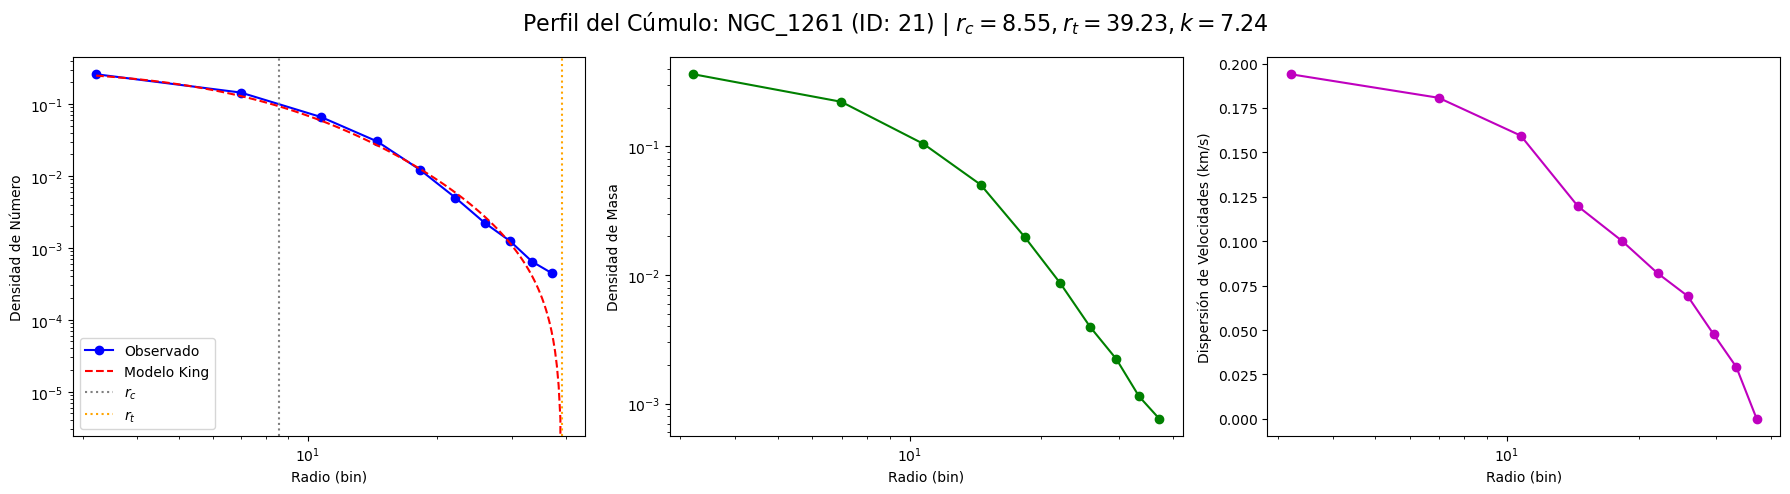

In [5]:
plot_cluster(21)

In [6]:
interact(plot_cluster, cluster_id=(0, 101, 1))

interactive(children=(IntSlider(value=50, description='cluster_id', max=101), Output()), _dom_classes=('widget…

<function __main__.plot_cluster(cluster_id)>